In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/interaction_type_bout.csv')
df1['condition'] = 'group-housed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/interaction_type_bout.csv')
df2['condition'] = 'social-isolated'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/interaction_type_bout.csv')
df3['condition'] = 'grouped+isolated'

# used by every cell below
DFS = [df1, df2, df3]
CONDITIONS = ['group-housed', 'social-isolated', 'grouped+isolated']
LABELS = {'group-housed': 'GH', 'social-isolated': 'SI', 'grouped+isolated': 'G+I'}
N_FILES = max(df['file'].nunique() for df in DFS)


In [2]:
import networkx as nx
from itertools import combinations
from scipy.stats import mannwhitneyu


def build_network(df, file):
    N_LARVAE = 10

    d = df[df['file'] == file]
    edges = d.groupby(['track_1', 'track_2']).agg(
        n_bouts=('bout_id', 'size'),
        total_duration=('duration', 'sum')).reset_index()

    G = nx.Graph()
    G.add_nodes_from(range(N_LARVAE))
    for _, r in edges.iterrows():
        G.add_edge(r.track_1, r.track_2, n_bouts=r.n_bouts, total_duration=r.total_duration)

    # node weight = that larva's total across all its partners
    for n in G.nodes:
        G.nodes[n]['n_bouts'] = G.degree(n, weight='n_bouts')
        G.nodes[n]['total_duration'] = G.degree(n, weight='total_duration')
    return G


def pairwise_p(summary, metric):
    # Mann-Whitney between each pair of conditions (one value per file)
    parts = []
    for a, b in combinations(CONDITIONS, 2):
        x = summary[summary['condition'] == a][metric]
        y = summary[summary['condition'] == b][metric]
        p = mannwhitneyu(x, y, alternative='two-sided').pvalue
        parts.append(f'{LABELS[a]}-{LABELS[b]} p={p:.3f}')
    return '  '.join(parts)


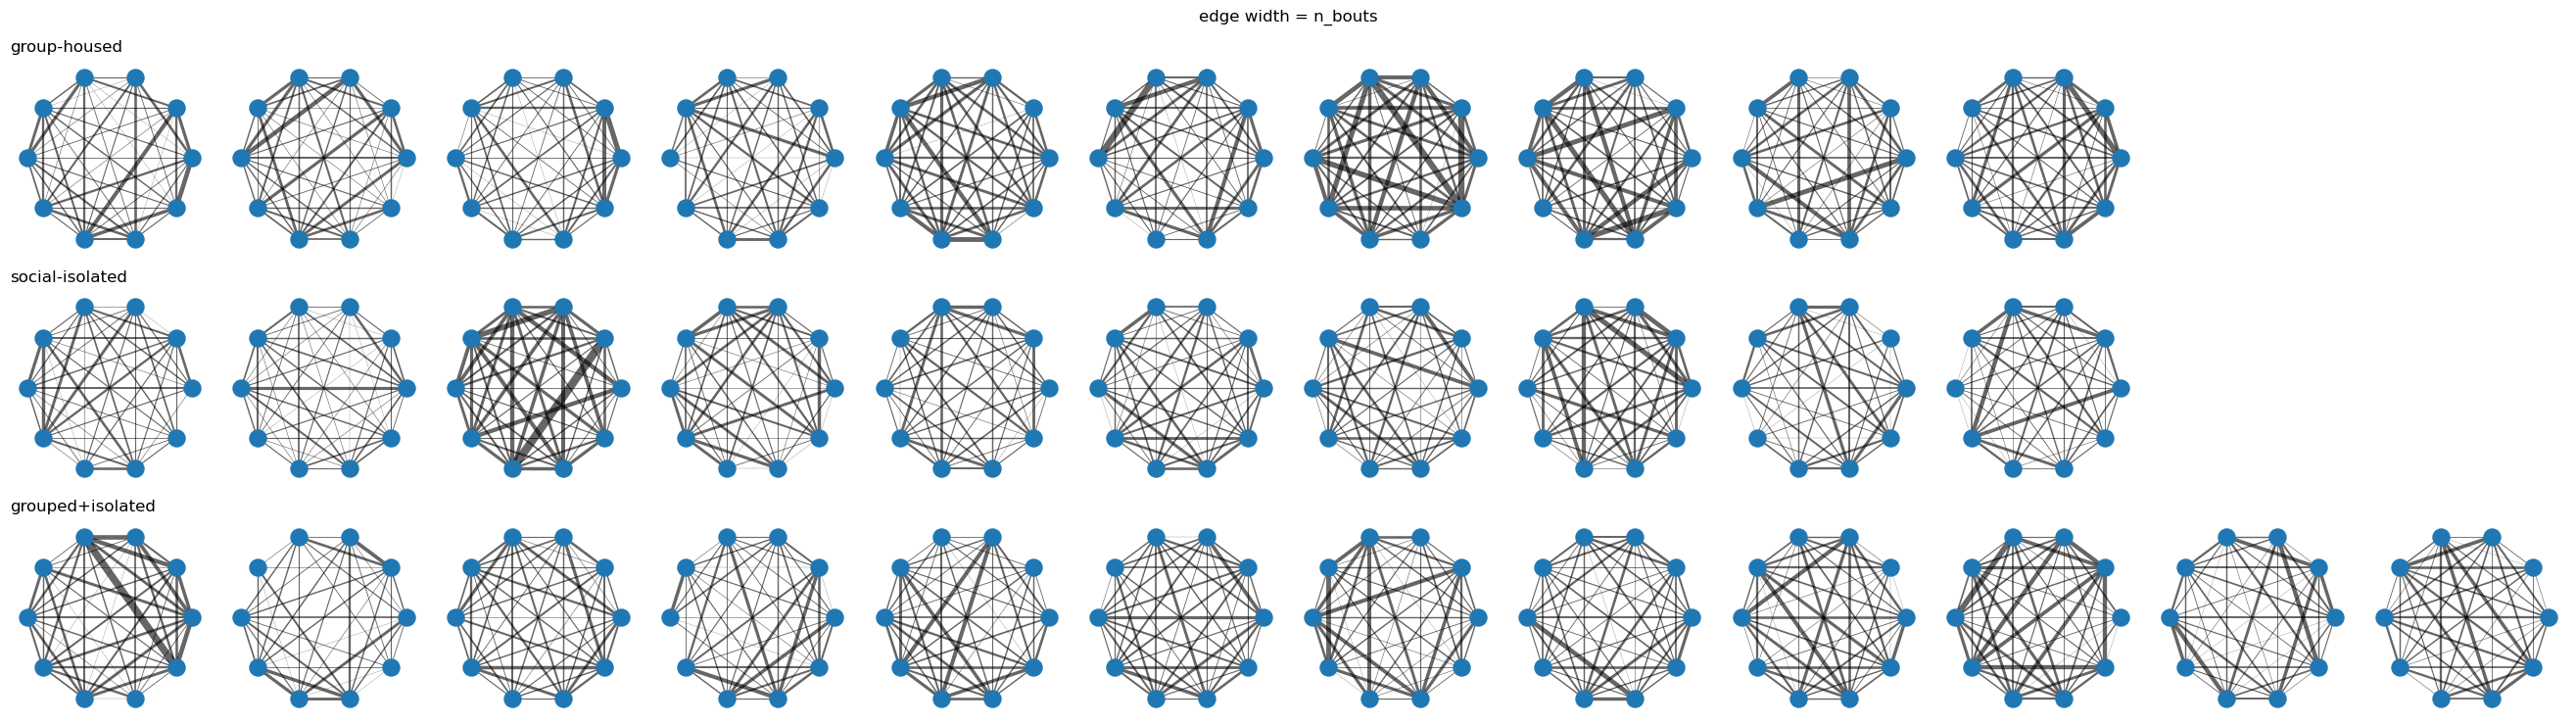

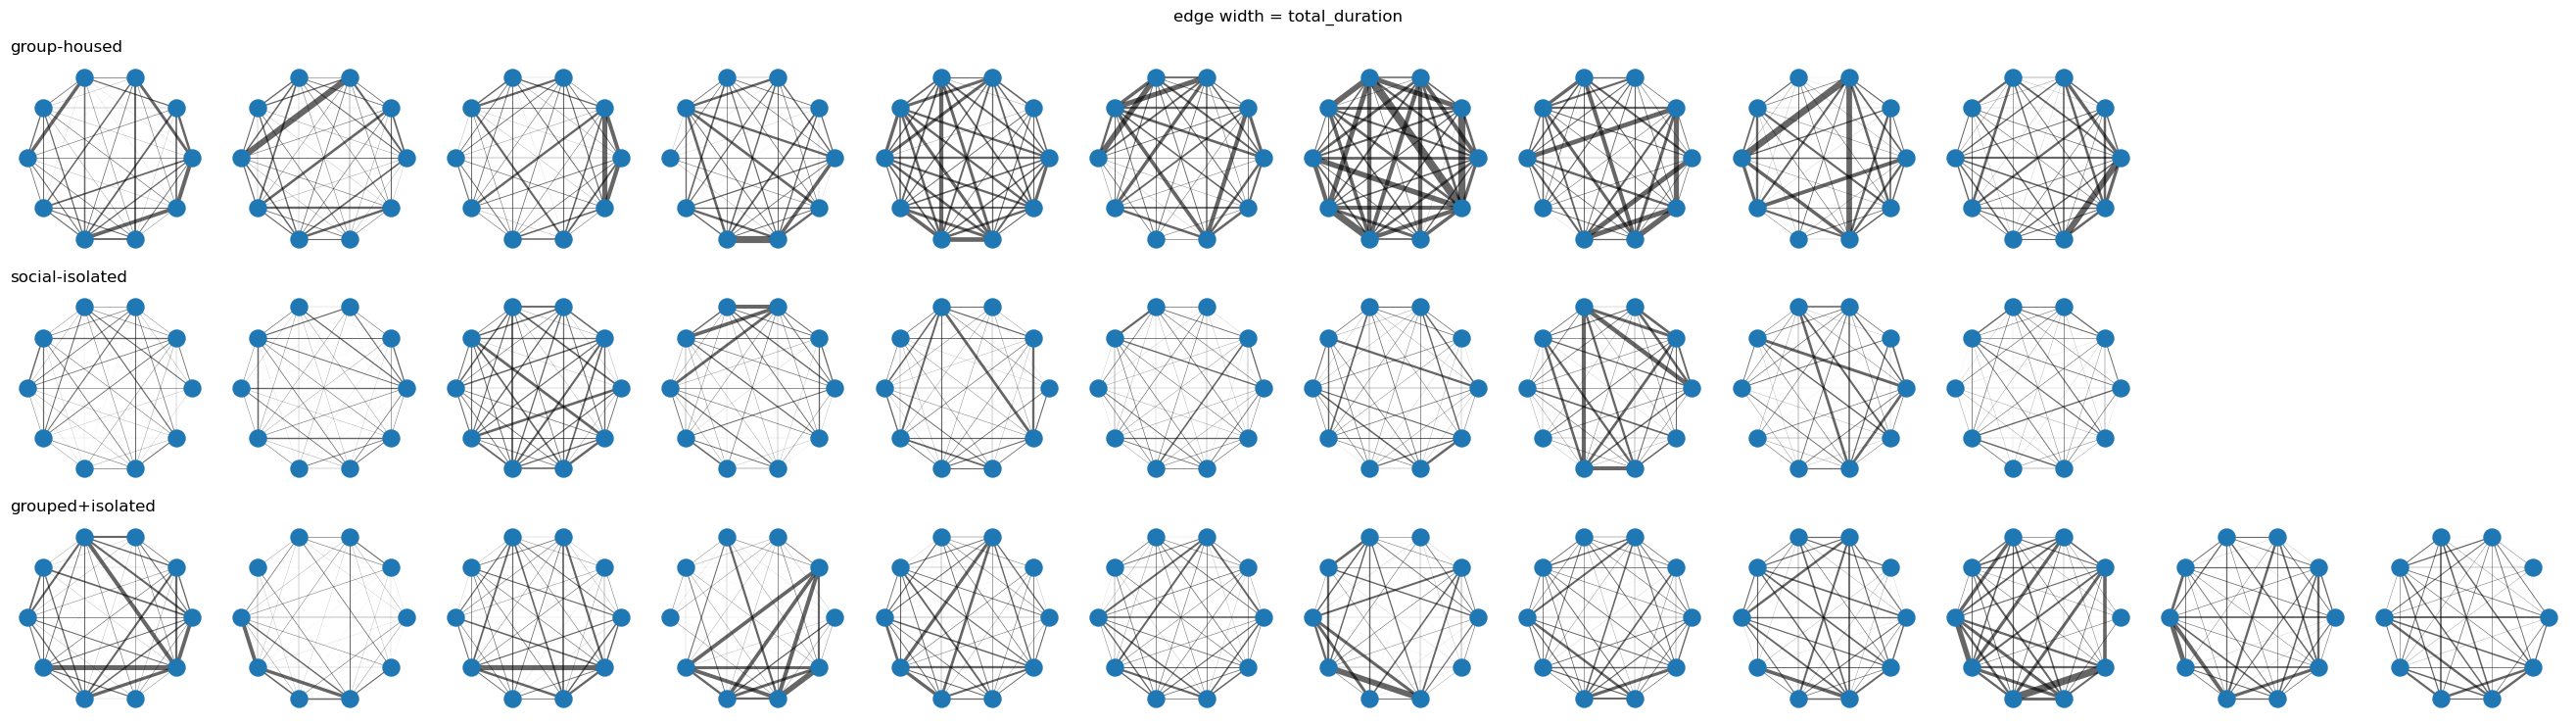

In [3]:
def plot_all_networks(weight):
    MAX_EDGE_WIDTH = 6
    NODE_SIZE = 150

    graphs = [[build_network(df, f) for f in df['file'].unique()] for df in DFS]

    # scale by the max across ALL conditions so they are comparable
    max_edge = max(G.edges[e][weight] for row in graphs for G in row for e in G.edges)

    fig, axes = plt.subplots(len(DFS), N_FILES, figsize=(N_FILES * 2.2, len(DFS) * 2.5))
    for ax in axes.ravel():
        ax.set_axis_off()
    for i, (condition, row) in enumerate(zip(CONDITIONS, graphs)):
        for j, G in enumerate(row):
            ax = axes[i, j]
            pos = nx.circular_layout(G)
            widths = [G.edges[e][weight] / max_edge * MAX_EDGE_WIDTH for e in G.edges]
            nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.6)
            nx.draw_networkx_nodes(G, pos, ax=ax, node_size=NODE_SIZE)
            if j == 0:
                ax.set_title(condition, loc='left')

    fig.suptitle(f'edge width = {weight}')
    plt.tight_layout()
    plt.show()

plot_all_networks('n_bouts')
plot_all_networks('total_duration')


In [4]:
rows = []
for df in DFS:
    for file in df['file'].unique():
        G = build_network(df, file)
        w = np.array([G.edges[e]['n_bouts'] for e in G.edges])
        rows.append({'condition': df['condition'].iloc[0], 'file': file,
                     'edges': G.number_of_edges(),
                     'mean_bouts_per_pair': w.mean(),
                     'cv_bouts_per_pair': w.std() / w.mean()})
summary = pd.DataFrame(rows)
summary


,condition,file,edges,mean_bouts_per_pair,cv_bouts_per_pair
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,44,5.750000,0.616132
1,group-housed,2025-02-24_12-01-01_td5.tracks.feather,45,5.533333,0.576050
2,group-housed,2025-02-24_17-38-55_td5.tracks.feather,45,5.311111,0.609559
3,group-housed,2025-02-28_13-00-52_td9.tracks.feather,42,5.428571,0.521248
4,group-housed,2025-03-03_11-40-39_td1.tracks.feather,44,8.113636,0.416482
5,group-housed,2025-03-03_11-41-22_td2.tracks.feather,44,6.545455,0.626926
6,group-housed,2025-03-04_17-08-33_td2.tracks.feather,45,10.000000,0.487625
7,group-housed,2025-03-07_14-59-00_td11.tracks.feather,45,8.466667,0.526795
8,group-housed,2025-03-10_15-37-02_td9.tracks.feather,45,6.177778,0.590367
9,group-housed,2025-03-31_17-02-11_td6.tracks.feather,45,7.088889,0.467221


## 1. variability between larvae  &  2. partner preference

In [5]:
def larva_metrics(G, weight):
    # 1. variability between larvae: CV of each larva's total
    strength = np.array([G.nodes[n][weight] for n in G.nodes])
    strength_cv = strength.std() / strength.mean()

    # 2. partner preference: share of each larva's total that is with its top partner
    shares = []
    for n in G.nodes:
        partner_w = [G.edges[n, m][weight] for m in G.neighbors(n)]
        if len(partner_w) > 0 and G.nodes[n][weight] > 0:
            shares.append(max(partner_w) / G.nodes[n][weight])
    top_partner_share = np.mean(shares)

    return strength_cv, top_partner_share


def shuffle_partners(d):
    # keep every bout (and its duration) but give it a random pair of larvae
    N_LARVAE = 10

    d = d.copy()
    pairs = np.array([np.random.choice(N_LARVAE, 2, replace=False) for _ in range(len(d))])
    d['track_1'] = pairs.min(axis=1)
    d['track_2'] = pairs.max(axis=1)
    return d


In [6]:
N_SHUFFLES = 100
WEIGHTS = ['n_bouts', 'total_duration']

rows = []
for df in DFS:
    for file in df['file'].unique():
        d = df[df['file'] == file]
        for weight in WEIGHTS:
            cv, share = larva_metrics(build_network(d, file), weight)

            null = [larva_metrics(build_network(shuffle_partners(d), file), weight) for _ in range(N_SHUFFLES)]
            null = np.array(null)

            rows.append({'condition': df['condition'].iloc[0], 'file': file, 'weight': weight,
                         'strength_cv': cv, 'strength_cv_null': null[:, 0].mean(),
                         'strength_cv_p': (null[:, 0] >= cv).mean(),
                         'top_partner_share': share, 'top_partner_share_null': null[:, 1].mean(),
                         'top_partner_share_p': (null[:, 1] >= share).mean()})

larva_summary = pd.DataFrame(rows)
larva_summary


,condition,file,weight,strength_cv,strength_cv_null,strength_cv_p,top_partner_share,top_partner_share_null,top_partner_share_p
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,n_bouts,0.143386,0.118060,0.19,0.234325,0.185899,0.00
1,group-housed,2025-02-24_11-59-11_td14.tracks.feather,total_duration,0.286017,0.193295,0.05,0.301516,0.235214,0.00
2,group-housed,2025-02-24_12-01-01_td5.tracks.feather,n_bouts,0.185957,0.122816,0.03,0.225678,0.186183,0.00
3,group-housed,2025-02-24_12-01-01_td5.tracks.feather,total_duration,0.278796,0.183123,0.01,0.286730,0.243434,0.02
4,group-housed,2025-02-24_17-38-55_td5.tracks.feather,n_bouts,0.218176,0.122469,0.00,0.215739,0.186875,0.01
...,...,...,...,...,...,...,...,...,...
59,grouped+isolated,2026-02-20_11-21-49_td12.tracks.feather,total_duration,0.396452,0.174818,0.00,0.279093,0.231094,0.00
60,grouped+isolated,2026-02-20_11-31-22_td14.tracks.feather,n_bouts,0.130555,0.117861,0.37,0.260214,0.185791,0.00
61,grouped+isolated,2026-02-20_11-31-22_td14.tracks.feather,total_duration,0.322964,0.205979,0.04,0.284996,0.250888,0.07
62,grouped+isolated,2026-02-20_11-36-03_td15.tracks.feather,n_bouts,0.225689,0.123820,0.01,0.211519,0.184242,0.01


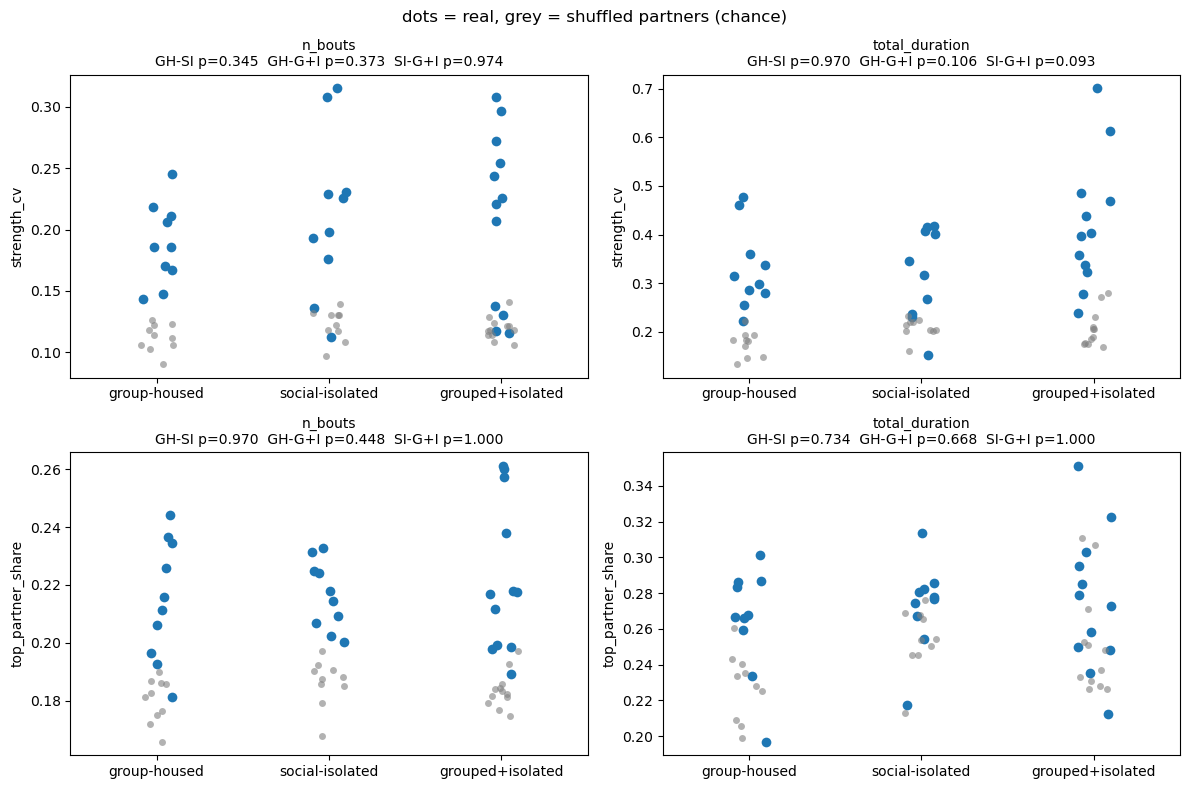

In [7]:
METRICS = ['strength_cv', 'top_partner_share']
WEIGHTS = ['n_bouts', 'total_duration']

fig, axes = plt.subplots(len(METRICS), len(WEIGHTS), figsize=(12, 8))
for i, metric in enumerate(METRICS):
    for j, weight in enumerate(WEIGHTS):
        ax = axes[i, j]
        s = larva_summary[larva_summary['weight'] == weight]

        sns.stripplot(data=s, x='condition', y=metric, order=CONDITIONS, ax=ax, size=7)
        sns.stripplot(data=s, x='condition', y=metric + '_null', order=CONDITIONS, ax=ax,
                      color='grey', size=5, alpha=0.6)

        ax.set_title(f'{weight}\n{pairwise_p(s, metric)}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel(metric)

fig.suptitle('dots = real, grey = shuffled partners (chance)')
plt.tight_layout()
plt.show()


In [8]:
# how many files per condition are beyond chance (p < 0.05 vs shuffled)
larva_summary.groupby(['weight', 'condition'])[['strength_cv_p', 'top_partner_share_p']].agg(lambda p: (p < 0.05).sum())


strength_cv_p  top_partner_share_p
weight         condition                                           
n_bouts        group-housed                  9                    8
               grouped+isolated              8                    8
               social-isolated               8                    7
total_duration group-housed                  9                    7
               grouped+isolated             11                    4
               social-isolated               6                    1

## super-interactors (node) vs preferences (edge), by total duration

In [9]:
def duration_matrix(d):
    # 10x10 matrix: total interaction duration between each pair of larvae
    N_LARVAE = 10

    M = np.zeros((N_LARVAE, N_LARVAE))
    np.add.at(M, (d['track_1'].values, d['track_2'].values), d['duration'].values)
    return M + M.T


def node_shares(M):
    # each larva's share of the file's total interaction time
    strength = M.sum(axis=1)
    return strength / strength.sum()


def preference_ratios(M):
    # observed / expected duration for each pair
    # expected = what the pair would get if larvae interacted in proportion to how social each is
    strength = M.sum(axis=1)
    iu = np.triu_indices(len(M), k=1)
    observed = M[iu]
    expected = np.outer(strength, strength)[iu]
    expected = expected / expected.sum() * observed.sum()
    return observed / expected


def shuffle_equal(d):
    # null for super-interactors: every bout gets a random pair (all larvae equal)
    N_LARVAE = 10

    d = d.copy()
    pairs = np.array([np.random.choice(N_LARVAE, 2, replace=False) for _ in range(len(d))])
    d['track_1'] = pairs.min(axis=1)
    d['track_2'] = pairs.max(axis=1)
    return d


def shuffle_keep_sociability(d):
    # null for preferences: shuffle partners but every larva keeps its own number of bouts
    # (so super-interactors stay super-interactors)
    d = d.copy()
    a = d['track_1'].values.copy()
    b = d['track_2'].values.copy()
    np.random.shuffle(b)
    loops = np.where(a == b)[0]
    while len(loops) > 0:
        for i in loops:
            j = np.random.randint(len(b))
            if b[j] != a[i] and b[i] != a[j]:
                b[i], b[j] = b[j], b[i]
        loops = np.where(a == b)[0]
    d['track_1'] = np.minimum(a, b)
    d['track_2'] = np.maximum(a, b)
    return d


In [10]:
N_SHUFFLES = 500
RATIO_CUTOFF = 2

rows = []
ranked = []    # for the rank plot
ratios = []    # for the ratio distribution plot
for df in DFS:
    condition = df['condition'].iloc[0]
    for file in df['file'].unique():
        d = df[df['file'] == file]
        M = duration_matrix(d)

        # 1. super-interactors
        shares = node_shares(M)
        node_cv = shares.std() / shares.mean()
        null_shares = np.array([node_shares(duration_matrix(shuffle_equal(d))) for _ in range(N_SHUFFLES)])
        null_node_cv = null_shares.std(axis=1) / null_shares.mean(axis=1)

        for rank, s in enumerate(np.sort(shares)[::-1]):
            ranked.append({'condition': condition, 'file': file, 'rank': rank + 1, 'share': s,
                           'null_share': np.sort(null_shares, axis=1)[:, ::-1][:, rank].mean()})

        # 2. preferences
        r = preference_ratios(M)
        pref_spread = r.std()
        pref_frac = (r > RATIO_CUTOFF).mean()
        null_r = np.array([preference_ratios(duration_matrix(shuffle_keep_sociability(d))) for _ in range(N_SHUFFLES)])
        null_spread = null_r.std(axis=1)
        null_frac = (null_r > RATIO_CUTOFF).mean(axis=1)

        ratios += [{'condition': condition, 'type': 'real', 'ratio': x} for x in r]
        ratios += [{'condition': condition, 'type': 'chance', 'ratio': x} for x in null_r[:20].ravel()]

        rows.append({'condition': condition, 'file': file,
                     'node_cv': node_cv, 'node_cv_null': null_node_cv.mean(),
                     'node_cv_p': (null_node_cv >= node_cv).mean(),
                     'pref_spread': pref_spread, 'pref_spread_null': null_spread.mean(),
                     'pref_spread_p': (null_spread >= pref_spread).mean(),
                     'pref_frac': pref_frac, 'pref_frac_null': null_frac.mean(),
                     'pref_frac_p': (null_frac >= pref_frac).mean()})

pref_summary = pd.DataFrame(rows)
ranked = pd.DataFrame(ranked)
ratios = pd.DataFrame(ratios)
pref_summary


,condition,file,node_cv,node_cv_null,node_cv_p,pref_spread,pref_spread_null,pref_spread_p,pref_frac,pref_frac_null,pref_frac_p
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0.286017,0.183807,0.030,0.812010,0.602418,0.006,0.088889,0.064933,0.326
1,group-housed,2025-02-24_12-01-01_td5.tracks.feather,0.278796,0.191700,0.026,0.682241,0.619621,0.162,0.133333,0.066978,0.032
2,group-housed,2025-02-24_17-38-55_td5.tracks.feather,0.360370,0.181653,0.002,0.707538,0.629653,0.118,0.088889,0.069333,0.366
3,group-housed,2025-02-28_13-00-52_td9.tracks.feather,0.460155,0.224448,0.000,0.700085,0.688477,0.424,0.066667,0.082711,0.806
4,group-housed,2025-03-03_11-40-39_td1.tracks.feather,0.222423,0.137306,0.012,0.414199,0.500198,0.956,0.022222,0.031022,0.792
5,group-housed,2025-03-03_11-41-22_td2.tracks.feather,0.314585,0.184612,0.002,0.625087,0.659673,0.684,0.044444,0.079511,0.938
6,group-housed,2025-03-04_17-08-33_td2.tracks.feather,0.254320,0.144556,0.000,0.509808,0.511898,0.488,0.022222,0.038444,0.884
7,group-housed,2025-03-07_14-59-00_td11.tracks.feather,0.298984,0.149237,0.000,0.652211,0.572345,0.104,0.066667,0.049822,0.384
8,group-housed,2025-03-10_15-37-02_td9.tracks.feather,0.476692,0.196269,0.000,1.039781,0.651130,0.000,0.088889,0.075022,0.446
9,group-housed,2025-03-31_17-02-11_td6.tracks.feather,0.337888,0.163823,0.000,0.625399,0.525231,0.032,0.088889,0.042444,0.084


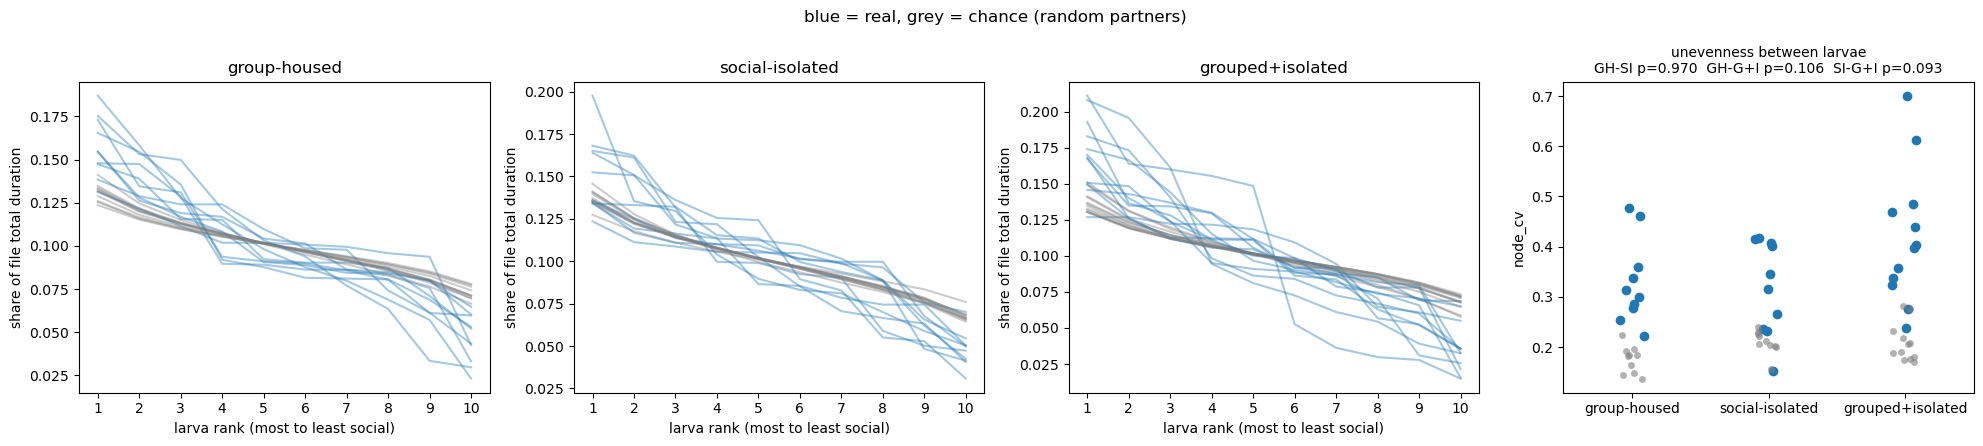

In [11]:
# 1. SUPER-INTERACTORS
fig, axes = plt.subplots(1, len(CONDITIONS) + 1, figsize=(20, 4.5))
for ax, condition in zip(axes, CONDITIONS):
    r = ranked[ranked['condition'] == condition]
    for file in r['file'].unique():
        f = r[r['file'] == file]
        ax.plot(f['rank'], f['share'], color='C0', alpha=0.4)
        ax.plot(f['rank'], f['null_share'], color='grey', alpha=0.4)
    ax.set_title(condition)
    ax.set_xlabel('larva rank (most to least social)')
    ax.set_ylabel('share of file total duration')
    ax.set_xticks(range(1, 11))

ax = axes[-1]
sns.stripplot(data=pref_summary, x='condition', y='node_cv', order=CONDITIONS, ax=ax, size=7)
sns.stripplot(data=pref_summary, x='condition', y='node_cv_null', order=CONDITIONS, ax=ax, color='grey', size=5, alpha=0.6)
ax.set_title(f"unevenness between larvae\n{pairwise_p(pref_summary, 'node_cv')}", fontsize=10)
ax.set_xlabel('')

fig.suptitle('blue = real, grey = chance (random partners)')
plt.tight_layout()
plt.show()


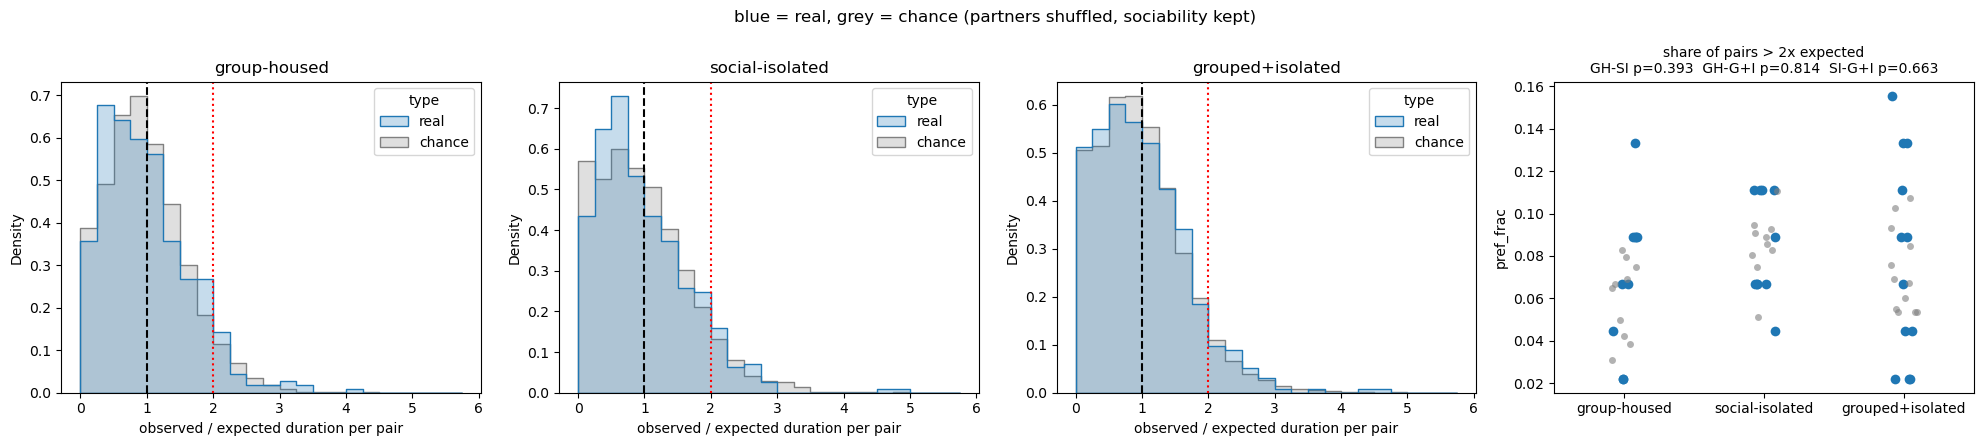

In [12]:
# 2. PREFERENCES (after removing super-interactors)
RATIO_CUTOFF = 2

fig, axes = plt.subplots(1, len(CONDITIONS) + 1, figsize=(20, 4.5))
for ax, condition in zip(axes, CONDITIONS):
    r = ratios[ratios['condition'] == condition]
    sns.histplot(data=r, x='ratio', hue='type', hue_order=['real', 'chance'], palette=['C0', 'grey'],
                 stat='density', common_norm=False, element='step', bins=np.arange(0, 6, 0.25), ax=ax)
    ax.axvline(1, color='k', ls='--')
    ax.axvline(RATIO_CUTOFF, color='r', ls=':')
    ax.set_title(condition)
    ax.set_xlabel('observed / expected duration per pair')

ax = axes[-1]
sns.stripplot(data=pref_summary, x='condition', y='pref_frac', order=CONDITIONS, ax=ax, size=7)
sns.stripplot(data=pref_summary, x='condition', y='pref_frac_null', order=CONDITIONS, ax=ax, color='grey', size=5, alpha=0.6)
ax.set_title(f"share of pairs > {RATIO_CUTOFF}x expected\n{pairwise_p(pref_summary, 'pref_frac')}", fontsize=10)
ax.set_xlabel('')

fig.suptitle('blue = real, grey = chance (partners shuffled, sociability kept)')
plt.tight_layout()
plt.show()


In [13]:
# how many files per condition are beyond chance (p < 0.05)
pref_summary.groupby('condition')[['node_cv_p', 'pref_spread_p', 'pref_frac_p']].agg(lambda p: (p < 0.05).sum())


,node_cv_p,pref_spread_p,pref_frac_p
condition,,,
group-housed,10,3,1
grouped+isolated,11,2,1
social-isolated,6,1,0


## interactions per larva, per file

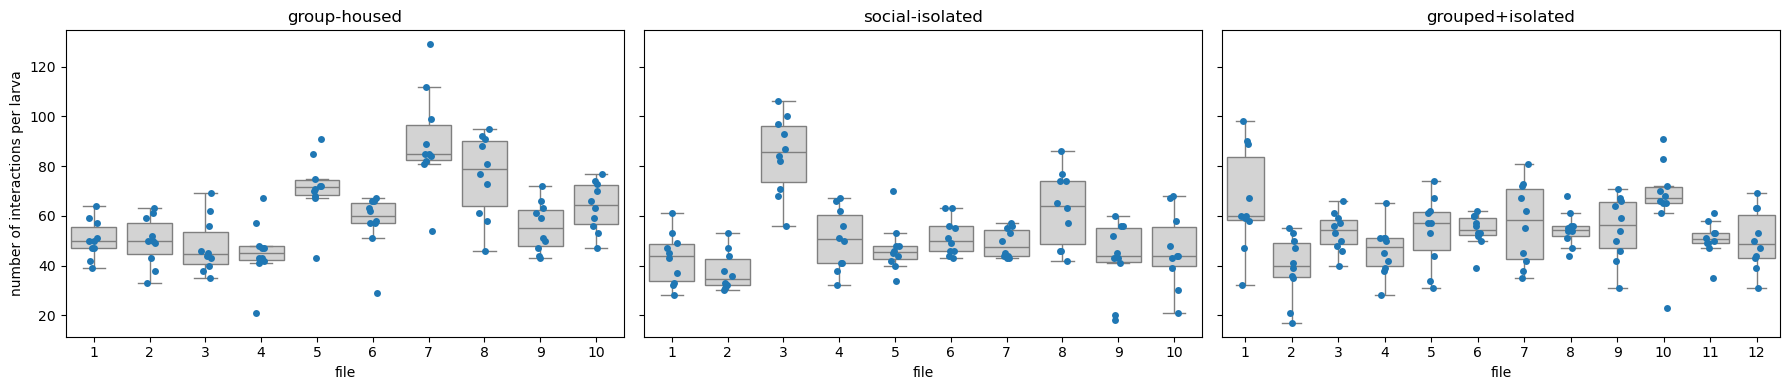

In [14]:
# number of interactions (bouts) each larva was involved in, per file
rows = []
for df in DFS:
    for i, file in enumerate(df['file'].unique()):
        d = df[df['file'] == file]
        # each bout counts for both larvae in it
        counts = pd.concat([d['track_1'], d['track_2']]).value_counts()
        for larva, n in counts.items():
            rows.append({'condition': df['condition'].iloc[0], 'file': file, 'file_n': i + 1,
                         'larva': larva, 'n_bouts': n})
per_larva = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(18, 4), sharey=True)
for ax, condition in zip(axes, CONDITIONS):
    s = per_larva[per_larva['condition'] == condition]
    sns.boxplot(data=s, x='file_n', y='n_bouts', ax=ax, color='lightgrey', showfliers=False)
    sns.stripplot(data=s, x='file_n', y='n_bouts', ax=ax, size=5)
    ax.set_title(condition)
    ax.set_xlabel('file')
    ax.set_ylabel('number of interactions per larva')

plt.tight_layout()
plt.show()


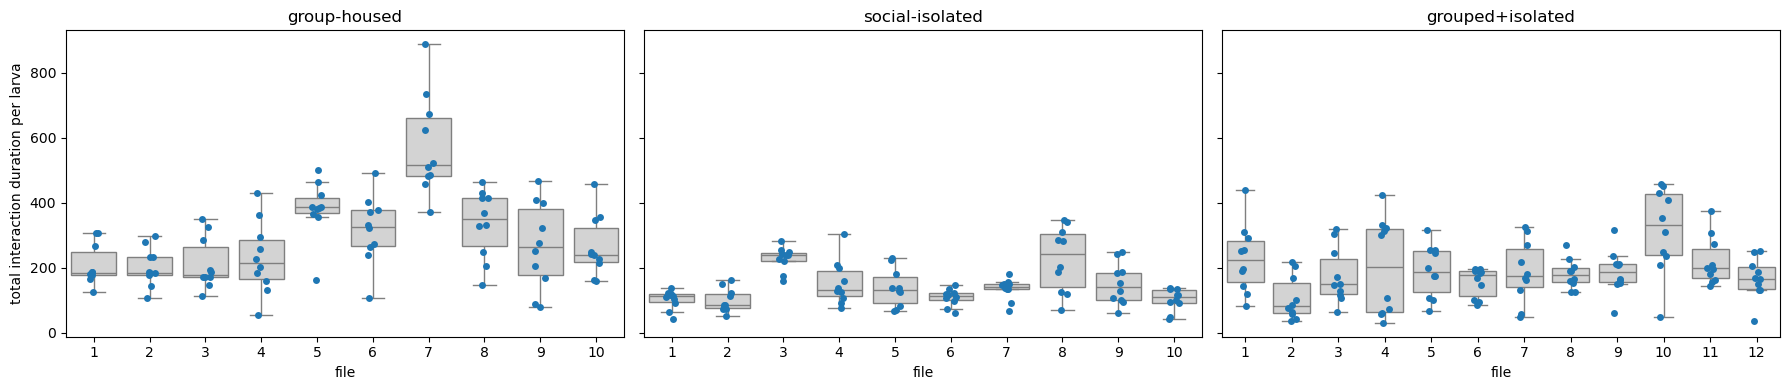

In [15]:
# total interaction duration each larva was involved in, per file
rows = []
for df in DFS:
    for i, file in enumerate(df['file'].unique()):
        d = df[df['file'] == file]
        # each bout's duration counts for both larvae in it
        both = pd.concat([d[['track_1', 'duration']].rename(columns={'track_1': 'larva'}),
                          d[['track_2', 'duration']].rename(columns={'track_2': 'larva'})])
        totals = both.groupby('larva')['duration'].sum()
        for larva, t in totals.items():
            rows.append({'condition': df['condition'].iloc[0], 'file': file, 'file_n': i + 1,
                         'larva': larva, 'total_duration': t})
per_larva_duration = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(18, 4), sharey=True)
for ax, condition in zip(axes, CONDITIONS):
    s = per_larva_duration[per_larva_duration['condition'] == condition]
    sns.boxplot(data=s, x='file_n', y='total_duration', ax=ax, color='lightgrey', showfliers=False)
    sns.stripplot(data=s, x='file_n', y='total_duration', ax=ax, size=5)
    ax.set_title(condition)
    ax.set_xlabel('file')
    ax.set_ylabel('total interaction duration per larva')

plt.tight_layout()
plt.show()


## does each larva start its bouts the same way? (initial_type)

In [16]:
# does each larva always start its bouts the same way? (initial_type)
# NOTE: types are pair labels (e.g. head_tail doesn't say which larva was the head)
N_SHUFFLES = 500
N_LARVAE = 10
TYPES = ['head_head', 'head_tail', 'body_head', 'body_tail', 'tail_tail', 'body_body']


def larva_type_table(d):
    # rows = larva, columns = initial type, values = number of bouts (each bout counts for both larvae)
    table = np.zeros((N_LARVAE, len(TYPES)))
    codes = pd.Categorical(d['initial_type'], categories=TYPES).codes
    np.add.at(table, (d['track_1'].values, codes), 1)
    np.add.at(table, (d['track_2'].values, codes), 1)
    return pd.DataFrame(table, columns=TYPES)


def consistency(table):
    # per larva: share of its bouts that are its most common type
    return (table.max(axis=1) / table.sum(axis=1)).values


rows = []
tables = {}
for df in DFS:
    condition = df['condition'].iloc[0]
    for i, file in enumerate(df['file'].unique()):
        d = df[df['file'] == file]
        table = larva_type_table(d)
        tables[(condition, i + 1)] = table
        real = consistency(table)

        # chance: shuffle the types between bouts in the same file
        null = []
        for _ in range(N_SHUFFLES):
            s = d.copy()
            s['initial_type'] = np.random.permutation(s['initial_type'].values)
            null.append(consistency(larva_type_table(s)))
        null = np.array(null)

        for larva in range(N_LARVAE):
            rows.append({'condition': condition, 'file': file, 'file_n': i + 1, 'larva': larva,
                         'top_type': table.loc[larva].idxmax(),
                         'consistency': real[larva], 'consistency_null': null[:, larva].mean(),
                         'p': (null[:, larva] >= real[larva]).mean()})

type_consistency = pd.DataFrame(rows)
type_consistency


,condition,file,file_n,larva,top_type,consistency,consistency_null,p
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,0,head_tail,0.440678,0.416000,0.324
1,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,1,head_tail,0.460000,0.418080,0.238
2,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,2,body_head,0.358974,0.430615,0.956
3,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,3,head_tail,0.357143,0.424333,0.978
4,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,4,body_head,0.382979,0.422298,0.828
...,...,...,...,...,...,...,...,...
315,grouped+isolated,2026-02-20_11-36-03_td15.tracks.feather,12,5,head_head,0.382979,0.451957,0.986
316,grouped+isolated,2026-02-20_11-36-03_td15.tracks.feather,12,6,head_tail,0.454545,0.455727,0.538
317,grouped+isolated,2026-02-20_11-36-03_td15.tracks.feather,12,7,head_head,0.487179,0.450564,0.302
318,grouped+isolated,2026-02-20_11-36-03_td15.tracks.feather,12,8,head_tail,0.428571,0.445333,0.728


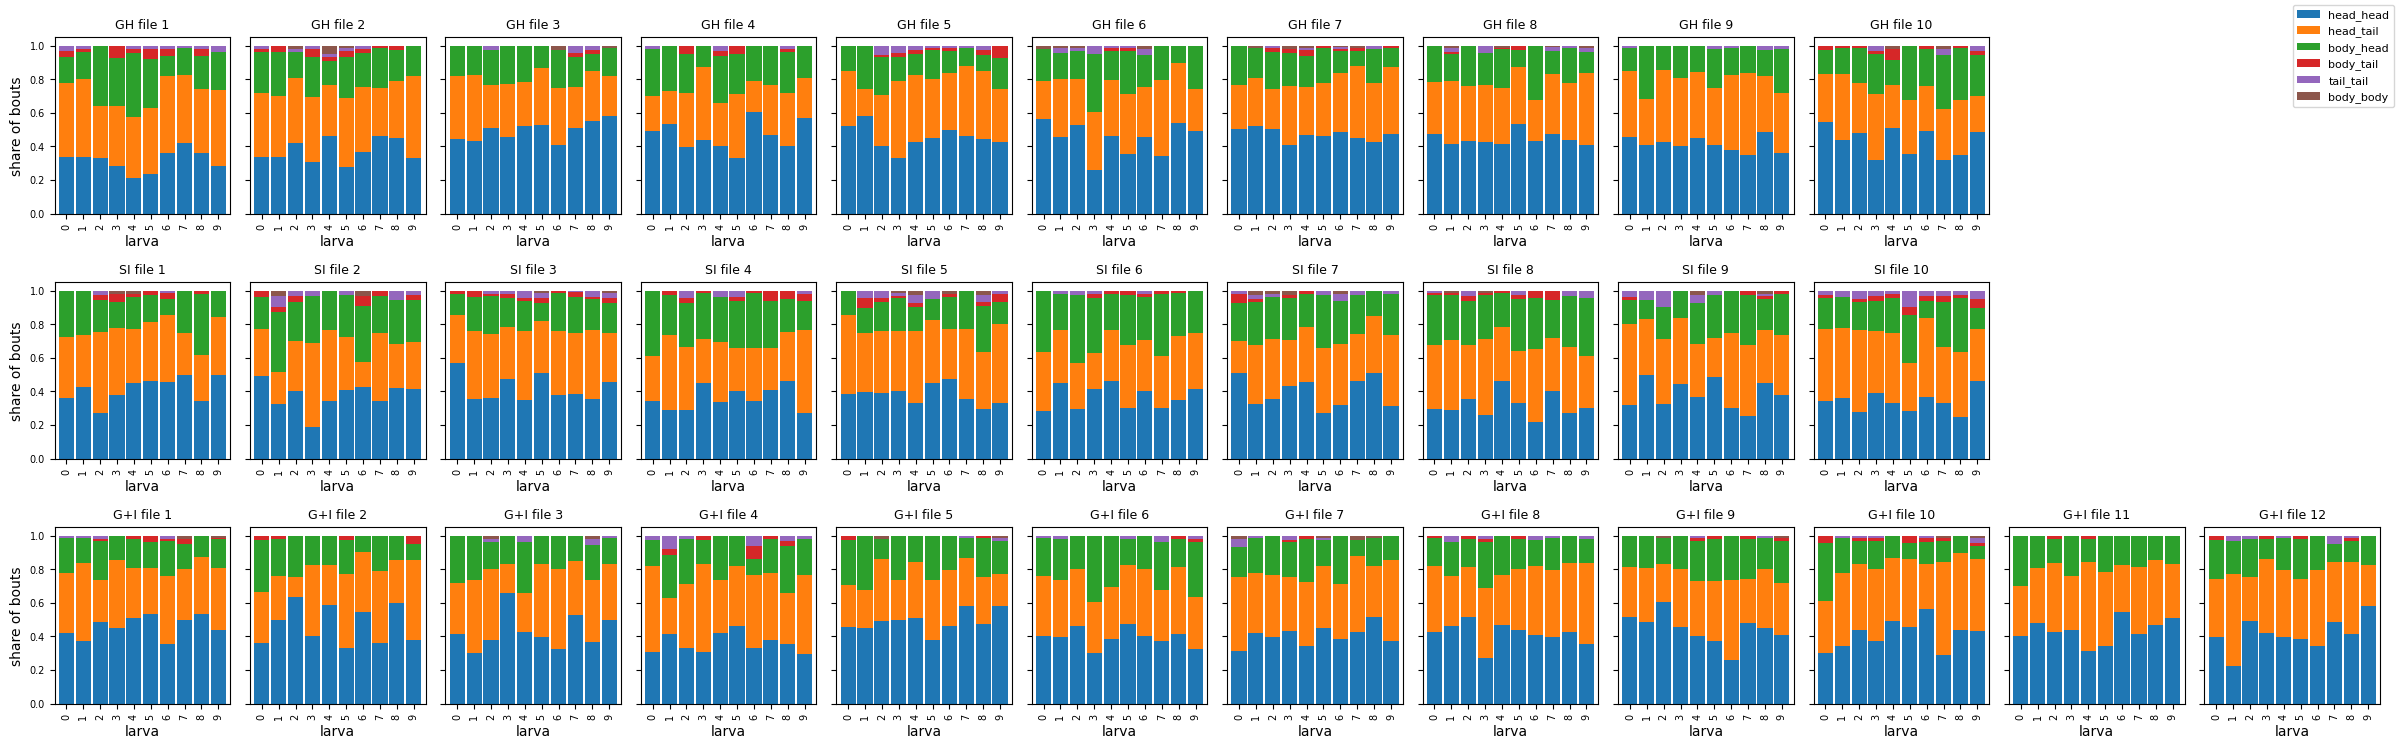

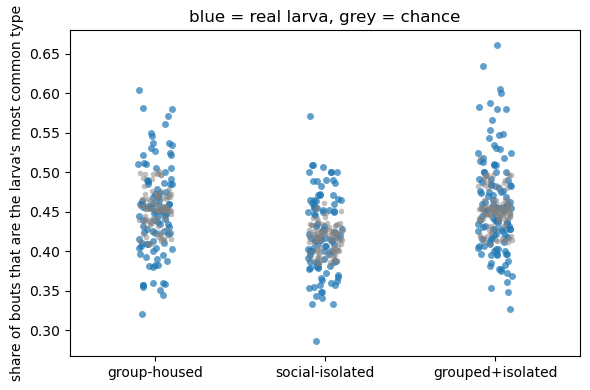

condition
group-housed        5
grouped+isolated    9
social-isolated     4
Name: p, dtype: int64

In [17]:
# plot 1: what types each larva starts with (one bar per larva, per file)
TYPES = ['head_head', 'head_tail', 'body_head', 'body_tail', 'tail_tail', 'body_body']

fig, axes = plt.subplots(len(CONDITIONS), N_FILES, figsize=(N_FILES * 2, len(CONDITIONS) * 2.5), sharey=True)
for i, condition in enumerate(CONDITIONS):
    for j in range(N_FILES):
        ax = axes[i, j]
        if (condition, j + 1) not in tables:
            ax.set_axis_off()
            continue
        t = tables[(condition, j + 1)]
        (t.div(t.sum(axis=1), axis=0)).plot.bar(stacked=True, ax=ax, width=0.9, legend=False)
        ax.set_title(f'{LABELS[condition]} file {j + 1}', fontsize=9)
        ax.set_xlabel('larva')
        ax.tick_params(labelsize=7)
    axes[i, 0].set_ylabel('share of bouts')
handles, _ = axes[0, 0].get_legend_handles_labels()
plt.tight_layout()
fig.legend(handles, TYPES, loc='upper right', fontsize=8)
plt.show()

# plot 2: consistency per larva vs chance
fig, ax = plt.subplots(figsize=(6, 4))
sns.stripplot(data=type_consistency, x='condition', y='consistency', order=CONDITIONS, ax=ax, size=5, alpha=0.7)
sns.stripplot(data=type_consistency, x='condition', y='consistency_null', order=CONDITIONS, ax=ax, color='grey', size=4, alpha=0.5)
ax.set_ylabel("share of bouts that are the larva's most common type")
ax.set_xlabel('')
ax.set_title('blue = real larva, grey = chance')
plt.tight_layout()
plt.show()

# how many larvae per condition are more consistent than chance (p < 0.05)
type_consistency.groupby('condition')['p'].agg(lambda p: (p < 0.05).sum())
